In [ ]:
#Parameters

Scenario = None
T_planet = None
M_planet = None
R_planet = None
G_planet = None
Z_planet = None
Age = None
v_sys = None

T_star = None
R_star = None
G_star = None
Z_star = None

folder_name = None
log_file = None


In [ ]:
#import the libraries 
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from scipy import fftpack,signal
from scipy import interpolate, special

import matplotlib
from matplotlib.ticker import ScalarFormatter
from astropy.visualization import (MinMaxInterval, SqrtStretch, ImageNormalize, ZScaleInterval)
import scipy
import json
import subprocess
import os
import emcee
import tqdm
import corner

from exocrires import spectra_2d
from exocrires import analysis
from exocrires import info
from exocrires import input_spectra_preparation

from astropy.io import fits
from astropy.table import Table


from exotic_ld import StellarLimbDarkening


from __future__ import print_function, division

from PyAstronomy import funcFit as fuf
from PyAstronomy import pyasl

import scipy.integrate as sci


path='/Users/richard/project_EXOCRIRES'

path_a='/Users/richard/project_EXOCRIRES/%s'%folder_name
lambda_range=info.lambda_range
simulation_parameters = pd.read_csv(path+'/'+log_file)
#data_atmos_transmission=np.loadtxt(path+'/%s/star/K2166/ascii_35/converted_data_%s_throughput_atmosphere_%s.txt'%(day, i,j),skiprows=1)

In [4]:
#adjust the plotting parameters rcParam for journal style plots, using times new roman font
#making the labels bold
plt.rcParams.update({'font.size': 20,
                     'font.family': 'Times New Roman',
                     'font.serif': ['Times New Roman'],
                     'font.sans-serif': ['Times New Roman'],
                     'font.monospace': ['Times New Roman'],
                     'font.weight': 'bold',
                     
                     'text.color': 'black',
                     'axes.labelcolor': 'black',
                     'xtick.color': 'black',
                     'ytick.color': 'black',
                     'axes.titleweight': 'regular',
                     'axes.labelweight': 'bold',
                     
                     'figure.figsize': (8, 6),
                     'figure.dpi': 300,
                     'axes.titlesize': 18,
                     'axes.labelsize': 18,
                     'legend.fontsize': 18,
                     'xtick.labelsize': 18,
                     'ytick.labelsize': 18,
                     'figure.autolayout': True
                    })



In [ ]:
#Using input_spectra_prepartion to produce input stellar and planetary spectra

# Round T and G to the nearest Phoenix ACES-AGSS-COND-2011 grid points:
#   Teff grid: 100 K steps (2300–7000 K)  → round to nearest 100 K
#   log g grid: 0.5 steps (0.0–6.0)       → round to nearest 0.5
# NOTE: file lte0{T_phoe}-{G_phoe}0{Z_star}.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits
# must exist in path_a/spectra_input/. Download missing files from:
# https://phoenix.astro.physik.uni-goettingen.de/data/v2.0/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/Z-0.0/
T_phoe = int((T_star / 100) * 100)    # e.g. 4377 → 4400
G_phoe = int((G_star * 2)) * 0.5            # e.g. 3.671 → 3.5

prep_star = input_spectra_preparation.Spectra_Preparator(
    path=path_a, folder_name='spectra_input', T=T_phoe, G=G_phoe, Z=Z_star
)
wavelength_range=info.lambda_range['wave']

#-----Prepare the stellar spectrum-----
band=-3
wave_range=info.lambda_range['wave'][band]
order_range=info.lambda_range['order'][band]




#-----upload teh rotational velocity vsini -----
Rot=5 #km/s, https://ui.adsabs.harvard.edu/abs/2006yCat..34630671R/abstract


#-----generate the broadened spectra-----
path_throughput = [path+'/throughput/SPHERE_IRDIS_B_Ks.dat', path+'/throughput/PARANAL_ERIS_Lp.dat']
ld_coefficients=prep_star.compute_limb_darkening(wavelength_range=info.lambda_range['wave'][-3:-1], throughput_files=path_throughput)

wave_phoe, flux_phoe = prep_star.load_phoenix_spectrum()

wave_phoe *= 1e-10 #Convert to meters

wave_lsf, flux_lsf_broaden=prep_star.apply_broadening(wave=wave_phoe, flux=flux_phoe, lam_range=wave_range,
                                                       ld_coeff=float(ld_coefficients[0]), rotation=Rot,
                                                         step_size='2x', interpolation='spline')

#-----Inject the BERV-----
v = 10 #km/s R.V. for Beta Pic
spec_shift = prep_star.radial_velocity_shift(wave=wave_lsf, flux=flux_lsf_broaden, velocity=v)

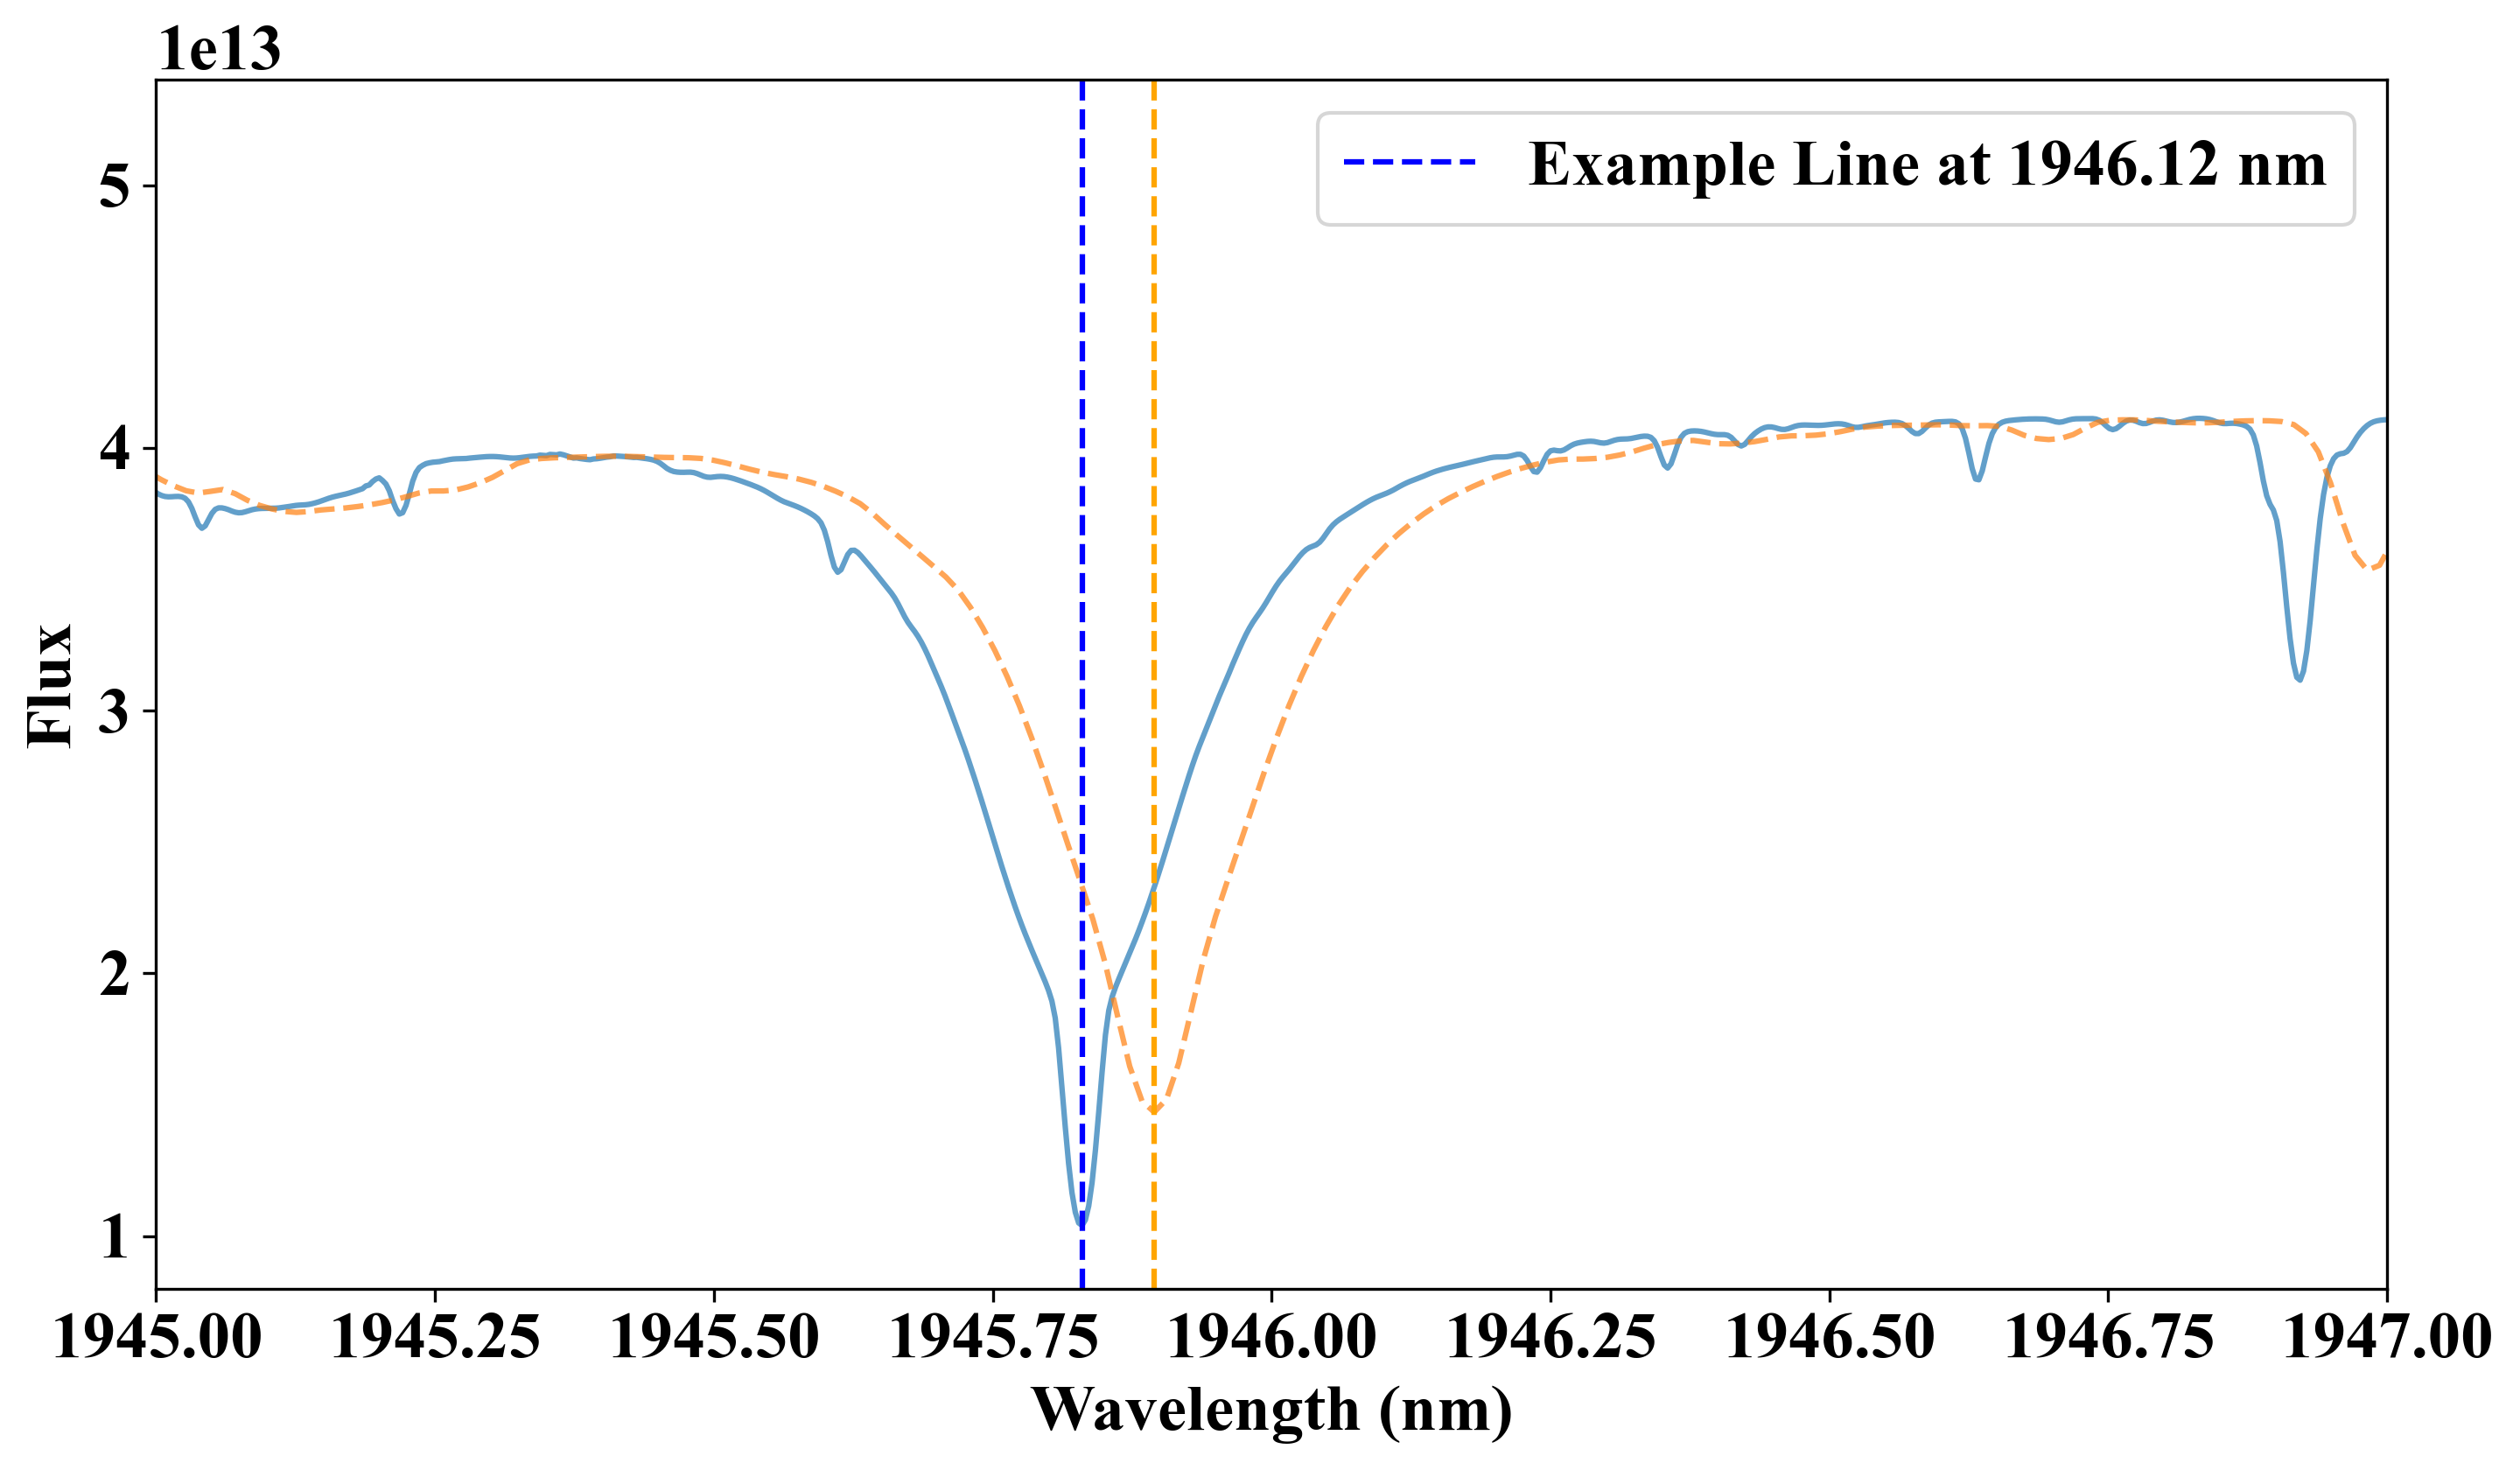

wavelength difference of the line center in angstroms: 0.6471923751209557
velocity difference of the line center in km/s: 9.978143647507066


In [10]:
#plot the broadened spectrum compared to the original phoenix spectrum
plt.figure(figsize=(10,6))
plt.plot(wave_phoe*1e9, flux_phoe, alpha=0.7)
plt.plot(spec_shift[:,0]*1e9, spec_shift[:,1], ls='--', alpha=0.7)

line_window = [1945.5, 1946.5] #nm

mask_line_window = (wave_phoe*1e9 >= line_window[0]) & (wave_phoe*1e9 <= line_window[1])
mask_line_window_broaden = (spec_shift[:,0]*1e9 >= line_window[0]) & (spec_shift[:,0]*1e9 <= line_window[1])

index_min = np.argmin(flux_phoe[mask_line_window]) + np.where(mask_line_window)[0][0]
index_min_broaden = np.argmin(spec_shift[:,1][mask_line_window_broaden]) + np.where(mask_line_window_broaden)[0][0]

plt.axvline(x=wave_phoe[index_min]*1e9, color='blue', ls='--', label='Example Line at 1946.12 nm')
plt.axvline(x=spec_shift[index_min_broaden, 0]*1e9, color='orange', ls='--')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux')
#plt.title('Stellar Spectrum Broadening')

plt.xlim(1945, 1947)
plt.ylim(0.8e13, 5.4e13)

plt.legend()
plt.show()

print ('wavelength difference of the line center in angstroms:', (spec_shift[index_min_broaden, 0]-wave_phoe[index_min])*1e10)
print ('velocity difference of the line center in km/s:', ((spec_shift[index_min_broaden, 0]-wave_phoe[index_min])/wave_phoe[index_min])*3e5)

In [49]:
#everything here in SI units

for v in np.arange(-100, 100, 1): #km/s

    for i in range(len(info.lambda_range['wave']))[-3:-2]:
    
        wavelengths = wave_lsf #m
        flux = flux_lsf_broaden*1e-8 #erg/s/cm2/A

        spec_shift = prep_star.radial_velocity_shift(wave=wavelengths, flux=flux, velocity=v)
        '''
        plt.plot(wavelengths, flux)
        plt.plot(wavelengths_shift, flux, label='shiftted spectrum')

        plt.xlim(wavelengths[1000], wavelengths[1000+50])
        plt.legend()
        plt.show()
        '''
        np.savetxt(prep_star.path+'/spectra_input/upload_star_lowres_%s_rot_lsf_%skm.dat'%(info.lambda_range['key'][i],v), spec_shift)

In [58]:
pc = 3.086e18 #cm

r_sun =  6.96e10 # solar radius in cm

Luminosity_sun = 3.828e33  # Solar luminosity in erg/s

Luminoisty_jup = 3.3e24  #Jupiter luminosity in erg/s

k_band_wave=np.array(info.lambda_range['wave'][-3])


spec_star=np.loadtxt(prep_star.path+'/spectra_input/upload_star_lowres_%s_rot_lsf_%skm.dat'%(info.lambda_range['key'][i], v_sys)).T



brightness_caculator = analysis.planet_para(data_planet=spec_star)

r_star = R_star*r_sun
throughput = np.loadtxt(path+'/throughput/SPHERE_IRDIS_B_Ks.dat')
throughput[:,0] = throughput[:,0]*1e-8 #from angstrom to cm
mag_K=brightness_caculator.mag_direct(radius=r_star, distance=140*pc, solid_angle=4*np.pi, band=k_band_wave*1e-9, transmission=throughput.T, zero=4.08361e-11)
print('magnitude in K band:', mag_K[0], mag_K[1], mag_K[2])  

#
#simulation_parameters.loc[simulation_parameters['Age']==Age, 'Mag_star_K'] = mag_K[0]


wavelength range: 1.92132389671829e-06 2.47238298463775e-06
magnitude in K band: 8.800489308473177 271367.78042569995 0.0003018591026124459


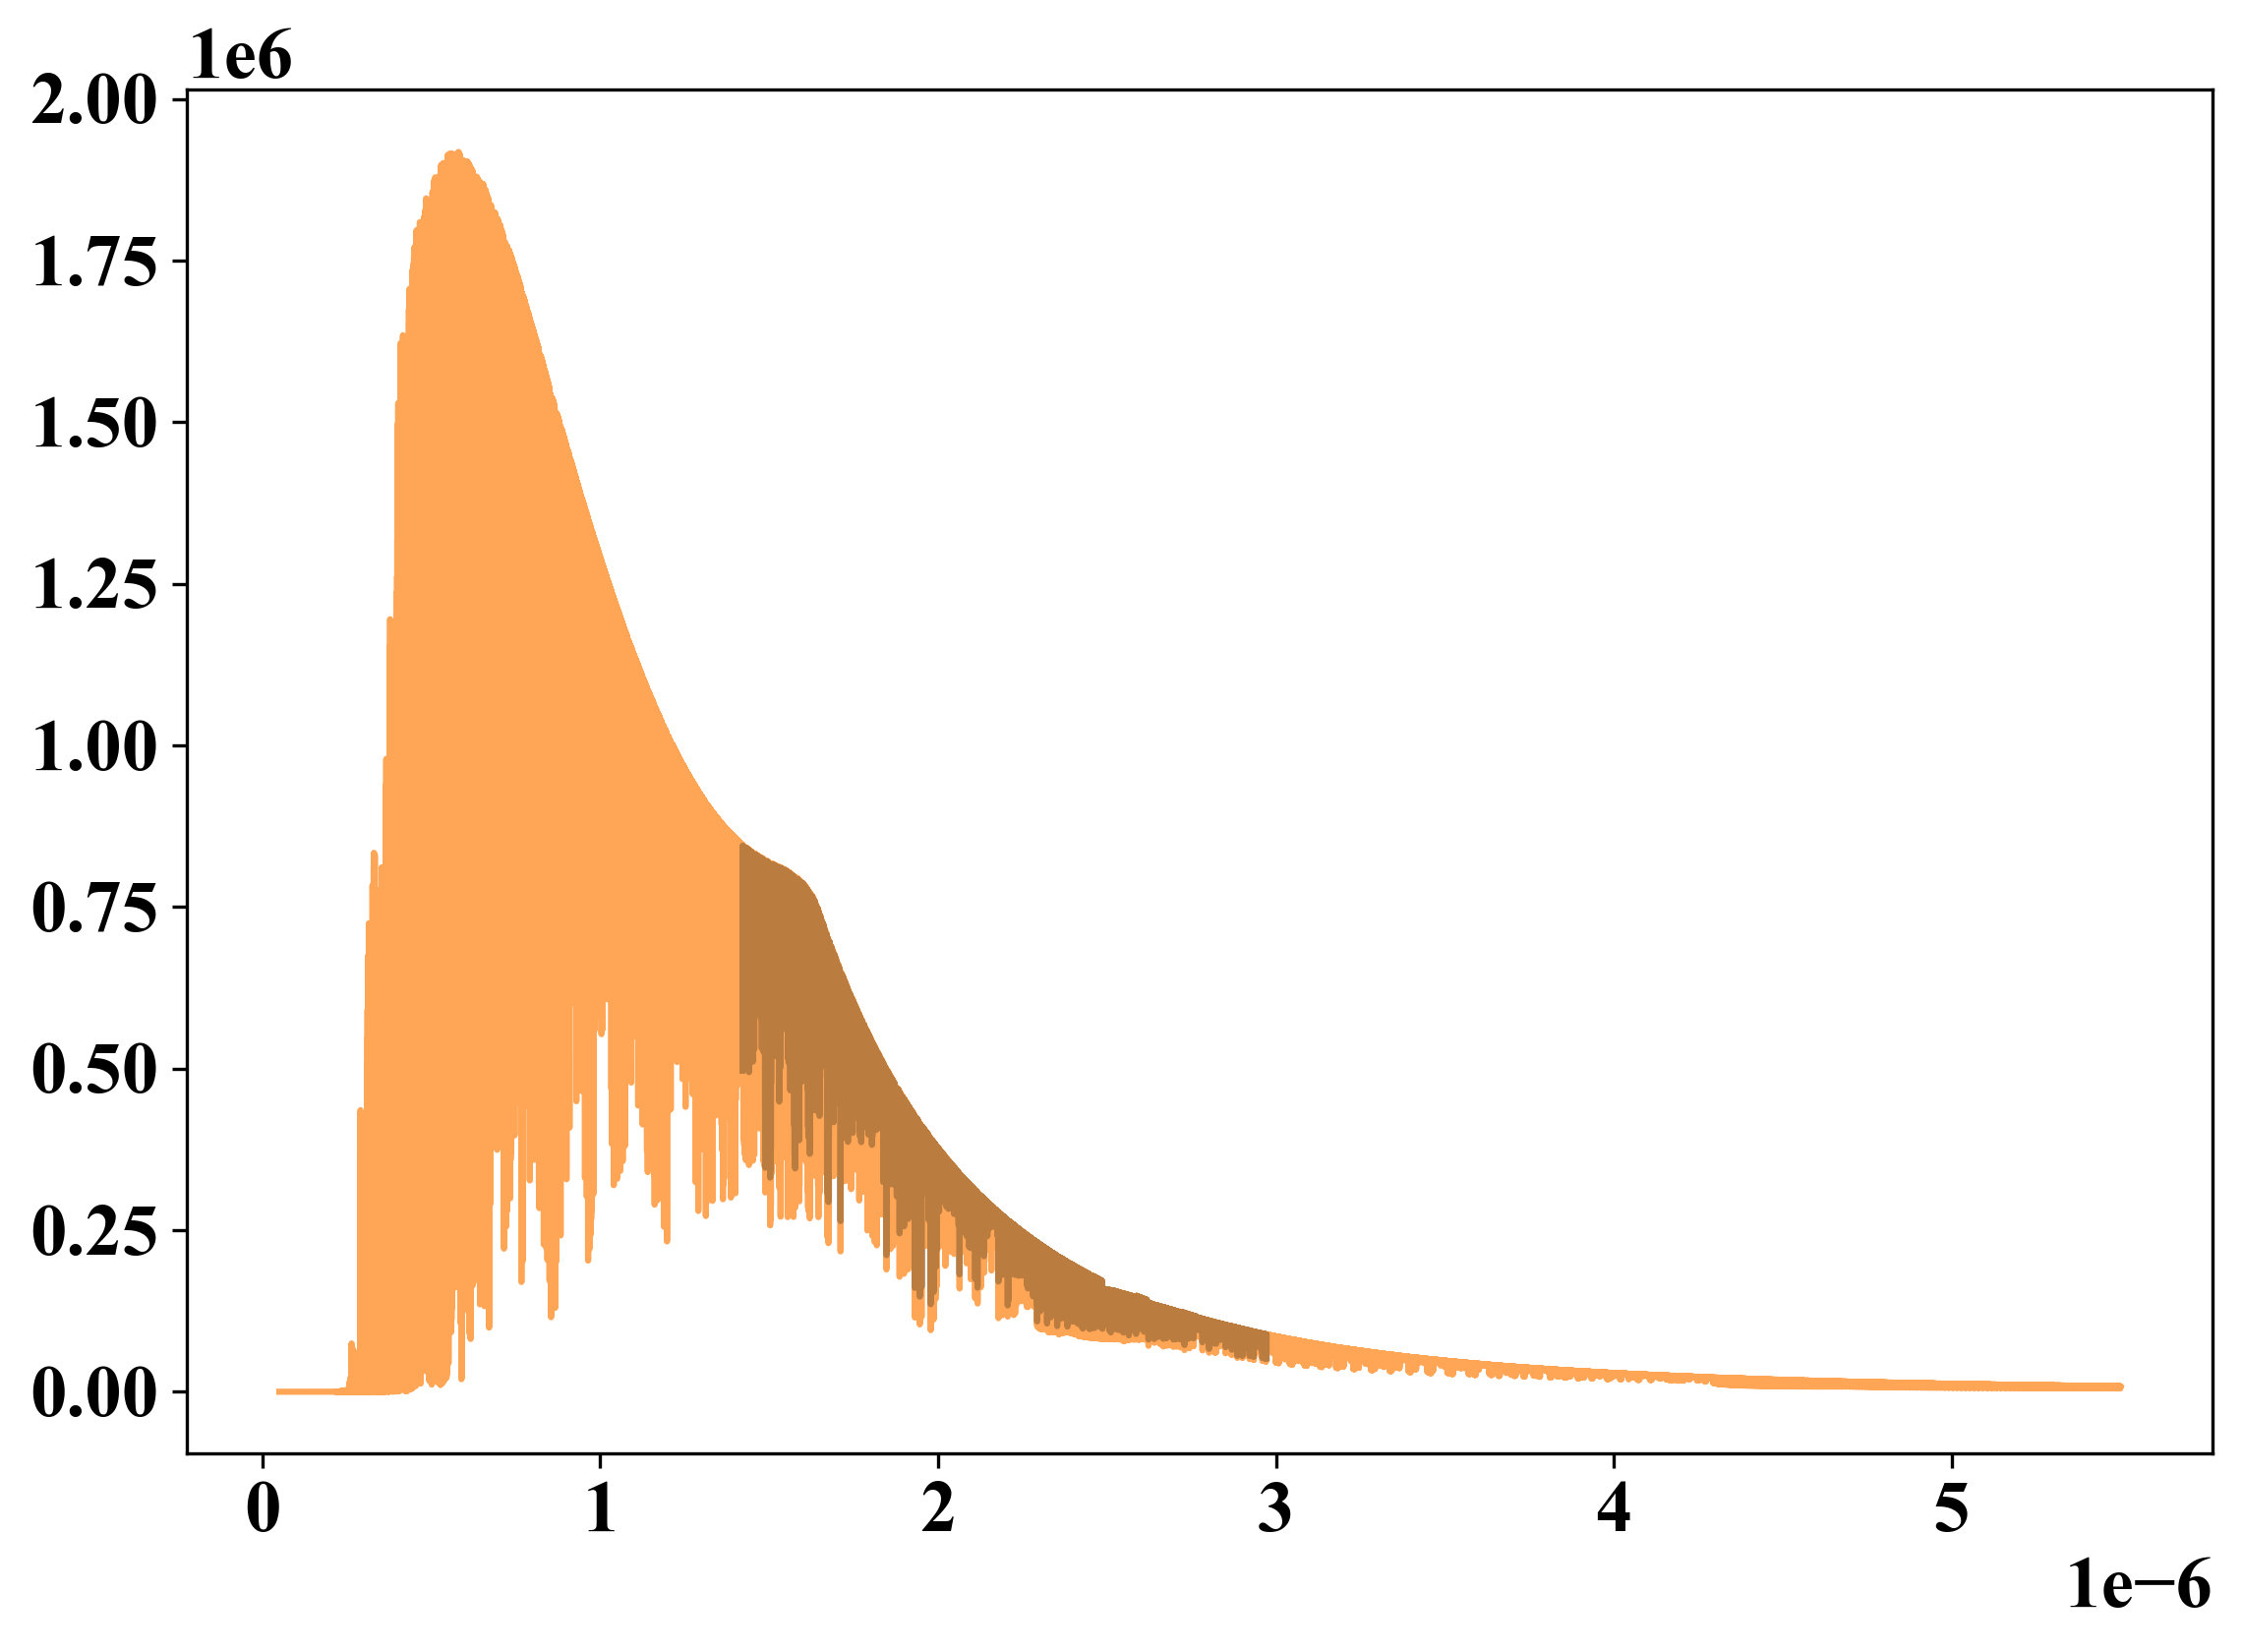

In [59]:
plt.plot(spec_star[0], spec_star[1])
plt.plot(wave_phoe, flux_phoe*1e-8, alpha=0.7)

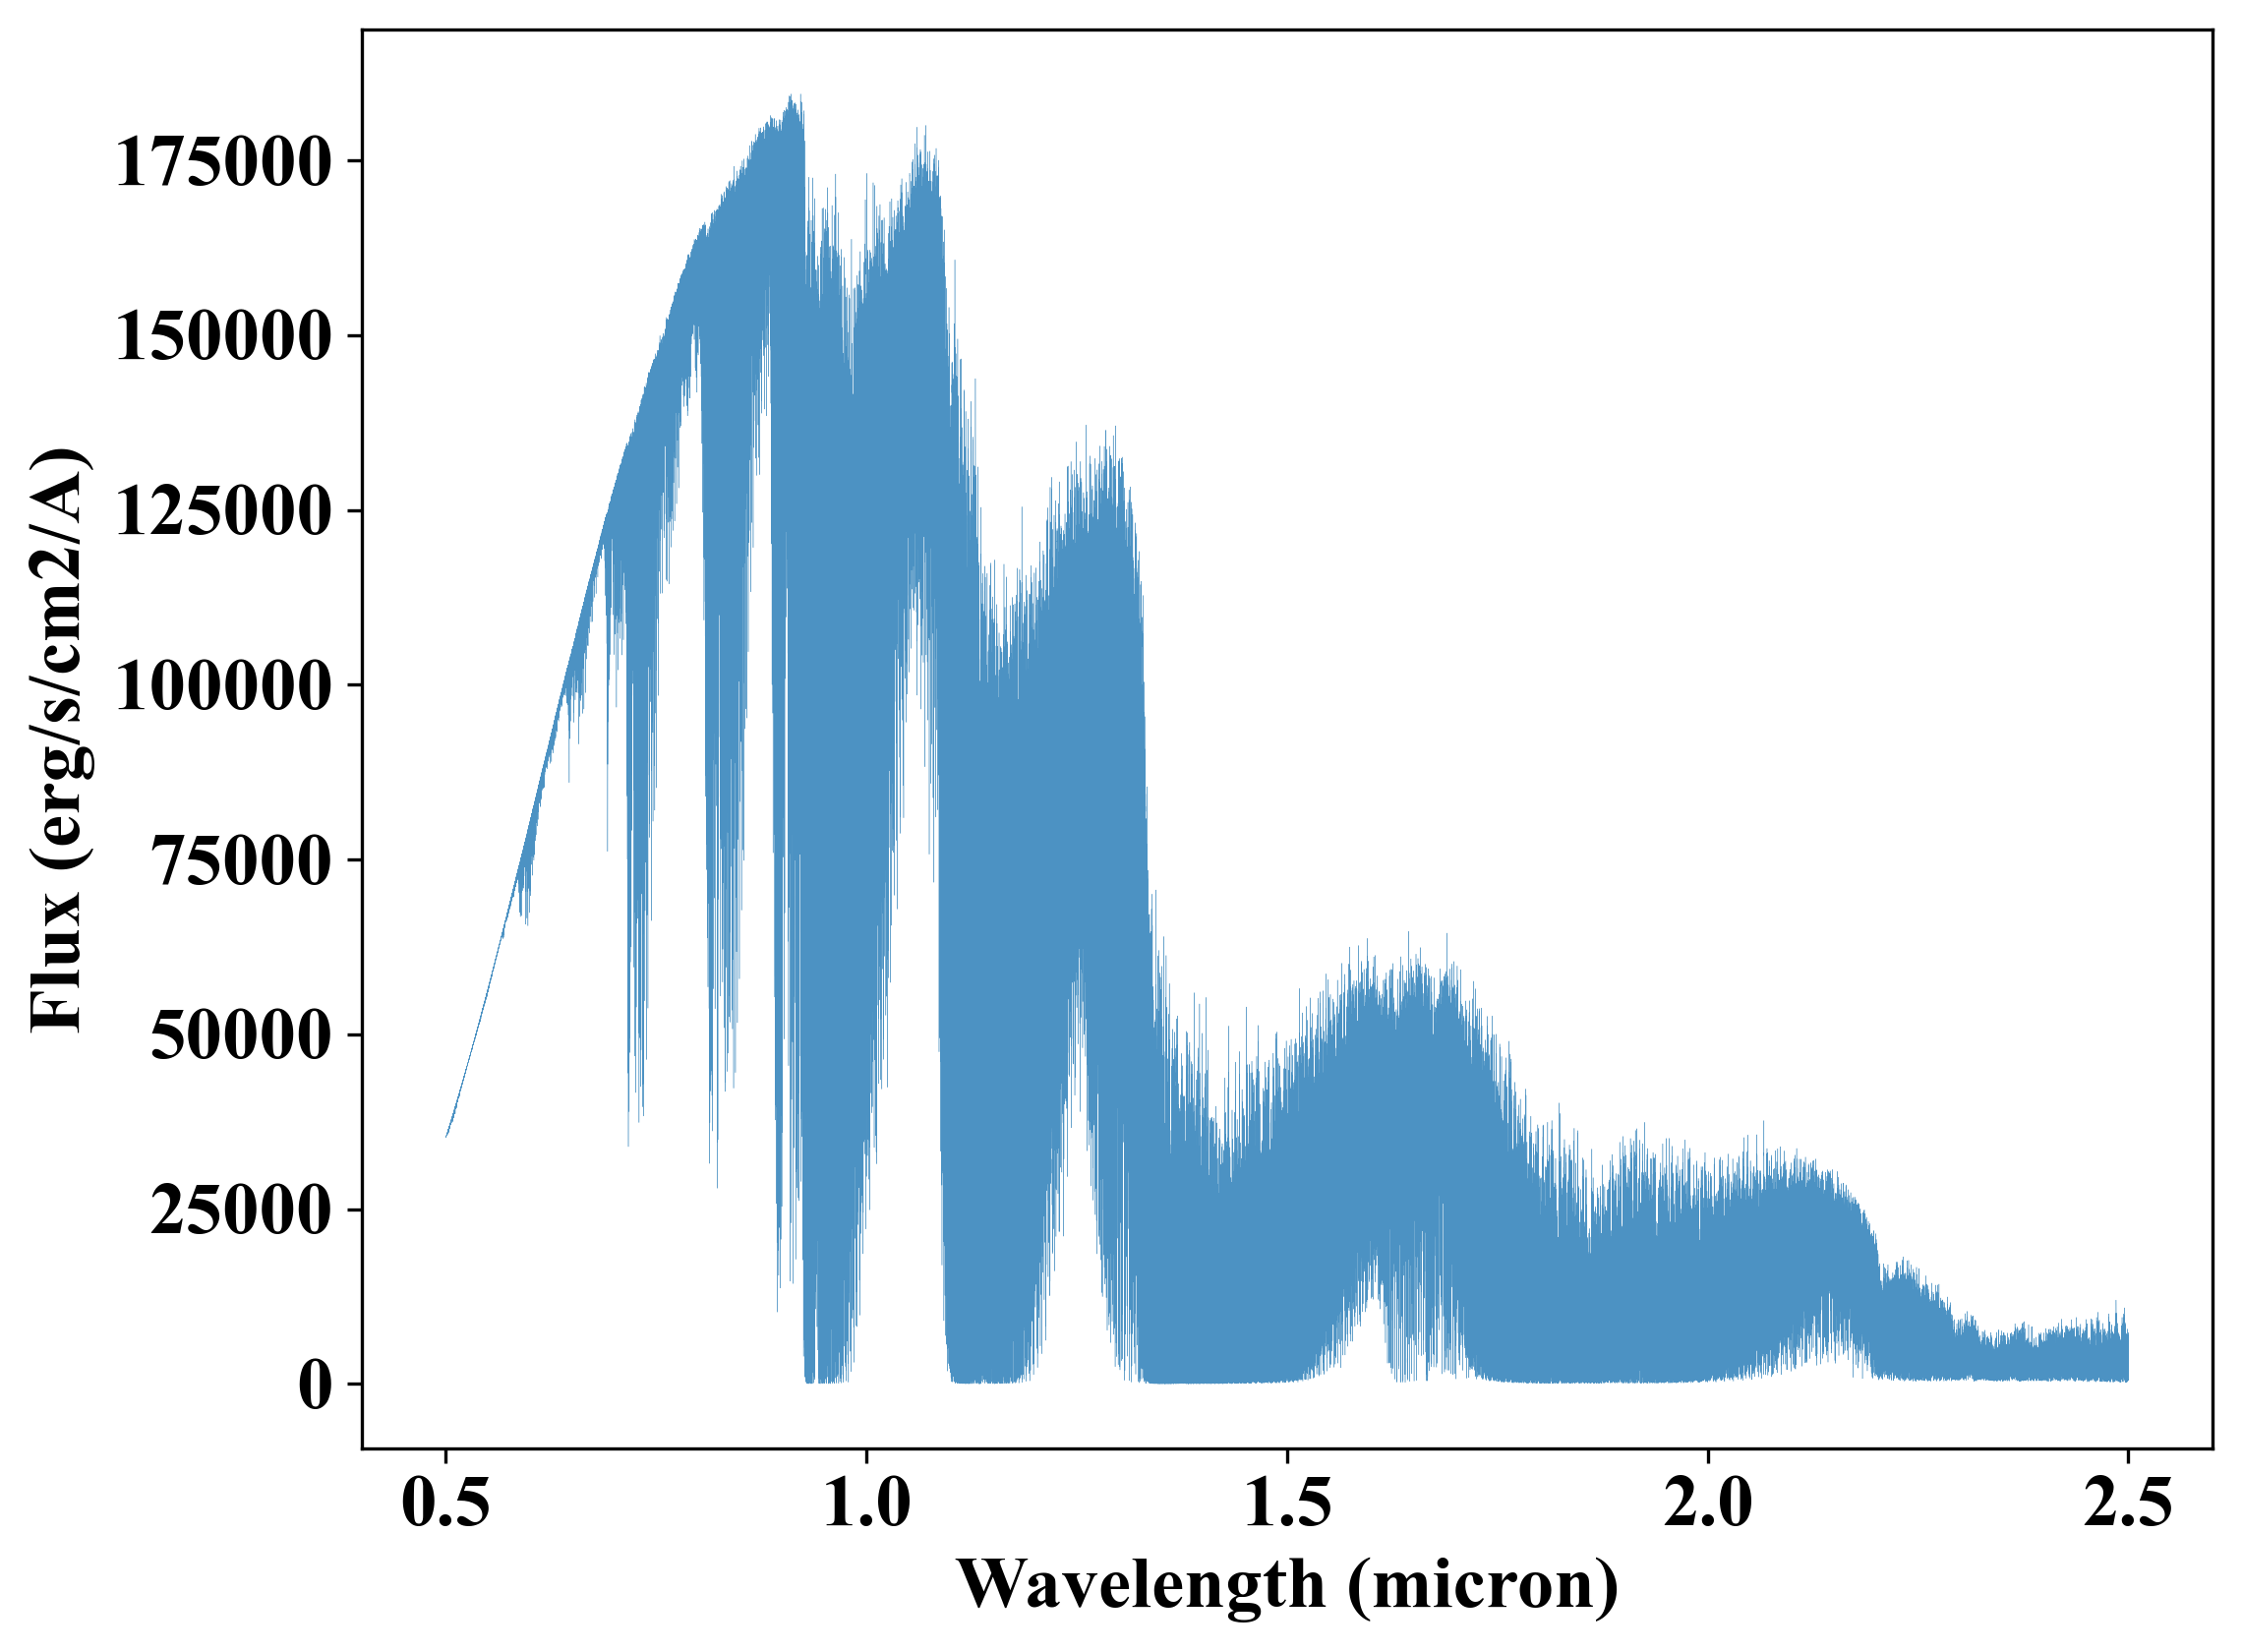

In [60]:
#Convert Lorenzo Spectra
#plot the forward model with T = 1700K

factor=1e-8

#flux_L=np.load(path+'/Beta_Pic/f_pRT_Kband_t1700_g100nc_m0.0.npy')
#wave_L=np.load(path+'/Beta_Pic/wave_pRT_Kband.npy')

G_p_m = int(10**(G_planet-2))

flux_K=np.load(path_a+f'/f_pRT_t{T_planet}_g{G_p_m}nc_m{Z_planet}.npy')
wave_K=np.load(path_a+'/wave_pRT.npy')

#plt.plot(wave_L, flux_L*factor, linewidth=0.1, alpha=0.8)


#plt.xlabel('Wavelength (micron)')
#plt.ylabel('Flux (erg/s/cm2/A)')

#plt.show()

plt.plot(wave_K, flux_K*factor, linewidth=0.1, alpha=0.8)

plt.xlabel('Wavelength (micron)')
plt.ylabel('Flux (erg/s/cm2/A)')
#plt.xlim(1.9, 2.2)
#plt.ylim(0, 4e-5)
plt.show()

#print (wave_L.min(), wave_L.max())

In [ ]:
#Prepare the planet spectrum
band=-3
wave_range=info.lambda_range['wave'][band:(band+1)]
order_range=info.lambda_range['order'][band:(band+1)]

prep_planet = input_spectra_preparation.Spectra_Preparator(folder_name='/spectra_input', T=T_planet, G=G_planet, Z=Z_planet, path='/Users/richard/project_EXOCRIRES')

Flux_planet = np.load(path_a+f'/f_pRT_t{T_planet}_g{G_p_m}nc_m{Z_planet}.npy')
Wave_planet = np.load(path_a+'/wave_pRT.npy')

Wave_planet *= 1e-6 #Convert to meters
Flux_planet *= 1e-8 #Convert to erg/s/cm2/A



ld_coefficients=prep_planet.compute_limb_darkening(wavelength_range=wave_range, \
                                                 throughput_files=[path_throughput[0]],\
                                                wave=Wave_planet*1e10, flux=Flux_planet, Mode='custom')



wave_lsf, flux_lsf_broaden=prep_planet.apply_broadening(wave=Wave_planet, flux=Flux_planet,\
                                                         lam_range=wave_range[0], ld_coeff=ld_coefficients[0],\
                                                         rotation=20, step_size='2x', interpolation='spline')

#-----Inject the RV-----
for v in tqdm.tqdm(np.arange(-100, 100, 1)):

    spec_shift = prep_planet.radial_velocity_shift(wave=wave_lsf, flux=flux_lsf_broaden, velocity=v)

    np.savetxt(path_a+'/spectra_input/upload_planet_lowres_%s_rot_lsf_%skm.dat'%(info.lambda_range['key'][-3],v), spec_shift)

    


/Users/richard/opt/anaconda3/lib/python3.9/site-packages/exotic_ld/ld_computation.py:650: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(ld_law_func,


Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 


100%|██████████| 200/200 [00:27<00:00,  7.22it/s]


In [ ]:
for mol in ['h2o_pokazatel', 'co', 'ch4']:

    Flux_planet=np.load(path_a+'/f_pRT_%s_only_t%s_g%snc_m0.0.npy'%(mol, T_planet, G_p_m))
    Flux_planet_no_mol = np.load(path_a+'/f_pRT_no_%s_t%s_g%snc_m0.0.npy'%(mol, T_planet, G_p_m))
    Wave_planet=np.load(path_a+'/wave_pRT.npy')

    Wave_planet *= 1e-6 #Convert to meters
    Flux_planet *= 1e-8 #Convert to erg/s/cm2/A



    ld_coefficients=prep_planet.compute_limb_darkening(wavelength_range=wave_range, \
                                                 throughput_files=[path_throughput[0]],\
                                                wave=Wave_planet*1e10, flux=Flux_planet, Mode='custom')



    wave_lsf, flux_lsf_broaden=prep_planet.apply_broadening(wave=Wave_planet, flux=Flux_planet,\
                                                         lam_range=wave_range[0], ld_coeff=ld_coefficients[0],\
                                                         rotation=20, step_size='2x', interpolation='spline')
    wave_lsf_no_mol, flux_lsf_broaden_no_mol=prep_planet.apply_broadening(wave=Wave_planet, flux=Flux_planet_no_mol,\
                                                         lam_range=wave_range[0], ld_coeff=ld_coefficients[0],\
                                                         rotation=20, step_size='2x', interpolation='spline')

    #-----Inject the RV-----
    for v in tqdm.tqdm(np.arange(-100, 100, 1)):

        spec_shift = prep_planet.radial_velocity_shift(wave=wave_lsf, flux=flux_lsf_broaden, velocity=v)
        spec_shift_no_mol = prep_planet.radial_velocity_shift(wave=wave_lsf_no_mol, flux=flux_lsf_broaden_no_mol, velocity=v)

        np.savetxt(path_a+'/spectra_input/upload_planet_lowres_%s_rot_lsf_%skm_%s_only.dat'%(info.lambda_range['key'][-3],v, mol), spec_shift)
        np.savetxt(path_a+'/spectra_input/upload_planet_lowres_%s_rot_lsf_%skm_no_%s.dat'%(info.lambda_range['key'][-3],v, mol), spec_shift_no_mol)

    

Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 
Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 


100%|██████████| 200/200 [00:54<00:00,  3.70it/s]


Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 
Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 


100%|██████████| 200/200 [00:51<00:00,  3.87it/s]


Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 
Sample grid is not equal. Use pyasl.equidistantInterpolation to produce equidistantly sampled data. 


100%|██████████| 200/200 [00:51<00:00,  3.87it/s]


In [64]:
pc = 3.086e18 #cm

r_jup = 7.1492e9  # Jupiter radius in cm

Luminosity_sun = 3.828e33  # Solar luminosity in erg/s

Luminoisty_jup = 3.3e24  #Jupiter luminosity in erg/s

k_band_wave=np.array(info.lambda_range['wave'][-3])

#flux_K=np.load(path+'/Beta_Pic/f_pRT_Kband_t1700_g31nc_m0.0.npy')
#wave_K=np.load(path+'/Beta_Pic/wave_pRT_Kband.npy')*1e-6

spec_planet=np.loadtxt(path_a+'/spectra_input/upload_planet_lowres_K2166_rot_lsf_10km.dat').T
#spec_planet=np.array([wave_K, flux_K])

brightness_caculator = analysis.planet_para(data_planet=spec_planet)

r_planet = R_planet*r_jup
mag_K=brightness_caculator.mag_direct(radius=r_planet, distance=140*pc, solid_angle=4*np.pi, band=k_band_wave*1e-9, transmission=throughput.T, zero=4.08361e-11)
print('magnitude in K band:', mag_K[0], mag_K[1], mag_K[2]) 

'''
simulation_parameters = pd.read_csv(path+'/simulation_log.csv')
simulation_parameters.loc[simulation_parameters['Age']==Age, 'Mag_planet_K'] = mag_K[0]
simulation_parameters.to_csv(path+'/simulation_log.csv', index=False)
'''

wavelength range: 1.9213240941961763e-06 2.47237908152394e-06
magnitude in K band: 16.977158695650814 10586.682955044393 1.6185887657878703e-07


"\nsimulation_parameters = pd.read_csv(path+'/simulation_log.csv')\nsimulation_parameters.loc[simulation_parameters['Age']==Age, 'Mag_planet_K'] = mag_K[0]\nsimulation_parameters.to_csv(path+'/simulation_log.csv', index=False)\n"

In [ ]:
#compare the original and broadened planet spectrum
Flux_planet = np.load(path_a+f'/f_pRT_t{T_planet}_g{G_p_m}nc_m{Z_planet}.npy')
Wave_planet = np.load(path_a+'/wave_pRT.npy')

Flux_planet *= factor #Convert to erg/s/cm2/A

plt.figure(figsize=(10,6))
plt.plot(Wave_planet*1e3, Flux_planet, alpha=0.7, label='Original pRT spectrum')
plt.plot(spec_planet[0]*1e9, spec_planet[1], ls='--', alpha=0.9, linewidth=2, label='Broadened spectrum')

plt.xlim(2164, 2168)
plt.ylim(0, 8e4)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux ($erg/s/cm^2/\AA$)')
#plt.title('Planet Spectrum Comparison')
plt.legend()
plt.show()